In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from pathlib import Path

DATABASE_DIR = Path.cwd() / 'database'

In [44]:
df_2 = pd.read_csv(DATABASE_DIR / '0_LOW_VOL_TRAINING.csv', index_col=0)
df_2 = df_2.dropna()
df_2.head()

,XAU_Returns,DXY_Returns,SPX_Returns,US10Y_Diff,VIX_Diff,Target_Next_Day_Gold
2010-06-16,-0.002758,0.001186,-0.000556,0.044,0.05000,0.011605
2010-06-22,-0.013943,0.004738,-0.020066,0.049,3.10000,-0.002302
2010-06-30,0.001346,-0.000070,-0.010164,-0.070,0.40999,-0.034735
2010-07-15,0.000952,-0.010459,0.001195,-0.074,0.25000,-0.013241
2010-07-28,0.003014,-0.000073,-0.006946,0.053,1.06000,0.003562


In [45]:
x = df_2[['XAU_Returns', 'DXY_Returns' , 'SPX_Returns', 'US10Y_Diff' , 'VIX_Diff']]
y = df_2['Target_Next_Day_Gold']

In [46]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3, random_state=42)

In [47]:
model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
model 

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [49]:

cdf = pd.DataFrame([model.intercept_] + list(model.coef_), index=['Intercept'] + list(x.columns), columns=['Coefficient'])

cdf.to_csv(DATABASE_DIR / '0_LOW_VOL_COEFFICIENTS.csv', index=True)

In [50]:
predictions = model.predict(x_test)
predictions

array([ 8.48752427e-04,  1.70487899e-03,  5.37585113e-04,  6.75514801e-04,
        2.23650656e-03,  2.35337828e-04,  2.01911207e-04, -3.15170975e-05,
       -1.61370886e-05,  1.54786195e-03,  3.87211358e-04,  1.49838511e-03,
        3.57744102e-04, -3.12781925e-04,  5.67266296e-04,  7.51960262e-04,
       -4.07180603e-04,  3.20440420e-04,  7.32435920e-04,  8.30620089e-05,
        2.02723966e-03,  4.27779427e-04,  7.58840730e-05,  7.99672915e-04,
       -6.91738664e-04,  1.91037857e-03,  2.97726621e-04, -1.97740824e-04,
        2.47541248e-04,  2.40906714e-04,  1.13837361e-03, -5.87388356e-05,
       -5.44708835e-05,  2.58422957e-04,  2.87397836e-05,  7.91718816e-05,
        4.33314181e-05, -1.96286296e-03,  4.78222590e-05,  1.19712114e-03,
        1.30698620e-03,  2.34424416e-04,  5.07796538e-04, -1.87200388e-04,
        1.70252734e-03,  1.58542689e-03,  4.94108901e-04,  2.48965506e-03,
        9.86976907e-04,  2.31649558e-04,  2.88233241e-03,  8.34730263e-04,
        8.30008068e-04,  

Text(0.5, 1.0, 'Evaluating the Linear Regression Model')

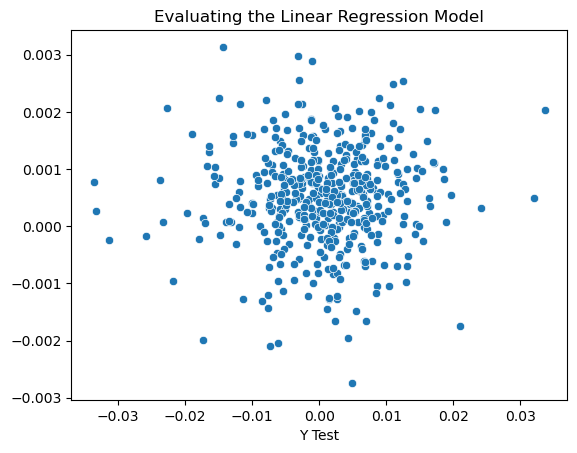

In [51]:
sns.scatterplot(x=y_test, y=predictions)
plt.xlabel('Y Test')
plt.title('Evaluating the Linear Regression Model')

In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

In [53]:
#residuals

#  if the residuals are not random it is a problem
residuals = y_test - predictions     

residuals

2011-03-08    0.000431
2013-01-18   -0.000826
2025-01-17    0.019117
2019-05-20   -0.003184
2016-01-29    0.006747
                ...   
2020-02-12    0.005235
2023-10-05    0.007495
2013-12-03    0.016176
2017-09-01    0.005407
2017-03-08   -0.006369
Name: Target_Next_Day_Gold, Length: 455, dtype: float64

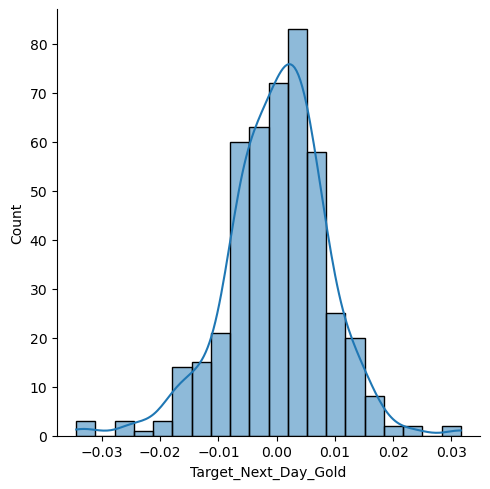

In [54]:
sns.displot(residuals, bins=20, kde=True)

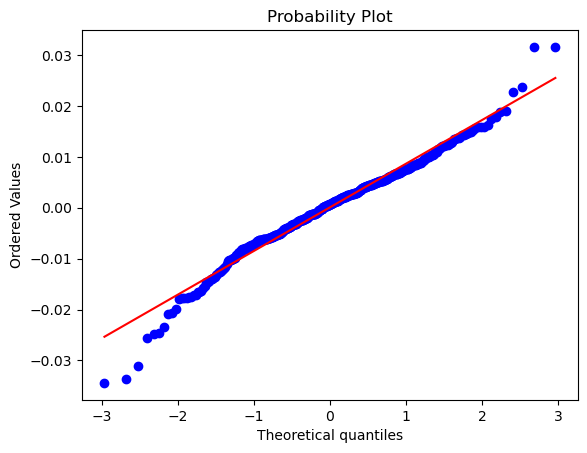

In [55]:
import pylab 
import scipy
from scipy import stats


stats.probplot(residuals, dist='norm', plot=pylab)
pylab.show()

In [56]:
# ==========================================
# 2. THE THRESHOLD FILTER (Directional Accuracy)
# ==========================================

# Calculate the "Noise Limit" (e.g., 0.5 * standard deviation of predictions)
# You can adjust this multiplier (0.5) to be more or less strict
threshold = 0.5 * np.std(predictions) 

# Create an array of 0s (Default state is FLAT / Do Not Trade)
predicted_direction = np.zeros(len(predictions))

# Only assign +1 (BUY) or -1 (SELL) if the prediction beats the threshold
predicted_direction[predictions > threshold] = 1
predicted_direction[predictions < -threshold] = -1

# The actual market direction
actual_direction = np.sign(y_test)

# Now, we only grade the test on days the bot ACTUALLY traded
# Find the indices where the bot did not sit flat (where prediction != 0)
trades_taken_idx = (predicted_direction != 0)

# Filter the arrays to only look at days we traded
actual_traded = actual_direction[trades_taken_idx]
predicted_traded = predicted_direction[trades_taken_idx]

# Calculate the new metrics
total_test_days = len(y_test)
total_trades_taken = len(predicted_traded)
correct_guesses = (actual_traded == predicted_traded).sum()

if total_trades_taken > 0:
    filtered_accuracy = (correct_guesses / total_trades_taken) * 100
else:
    filtered_accuracy = 0.0

print(f"Total Test Days:      {total_test_days}")
print(f"Trades Actually Taken:{total_trades_taken} (Ignored {total_test_days - total_trades_taken} noisy days)")
print(f"Correct Directions:   {correct_guesses}")
print(f"Filtered Accuracy:    {filtered_accuracy:.2f}%")

Total Test Days:      455
Trades Actually Taken:305 (Ignored 150 noisy days)
Correct Directions:   154
Filtered Accuracy:    50.49%
